<a href="https://colab.research.google.com/github/MeenakshiGanesan/bdml-lab/blob/main/build7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
Epoch 0, D Loss: [0.6571295 0.7392578], G Loss: 0.682138979434967
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
8/8 ━━━━━━━━━━━━━

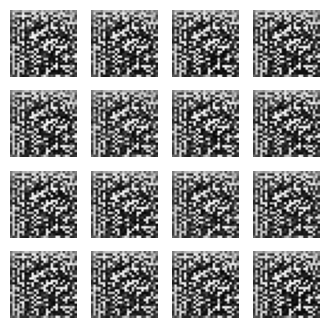

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')
x_train = (x_train - 127.5) / 127.5
batch_size = 256
latent_dim = 100

generator = tf.keras.Sequential([
    layers.Dense(7*7*256, input_dim=latent_dim),
    layers.Reshape((7,7,256)),
    layers.BatchNormalization(),
    layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', activation='relu'),
    layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', activation='relu'),
    layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', activation='tanh')
])

discriminator = tf.keras.Sequential([
    layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=(28,28,1)),
    layers.LeakyReLU(0.2),
    layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
    layers.LeakyReLU(0.2),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

epochs = 50
for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise)
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, D Loss: {0.5 * np.add(d_loss_real, d_loss_fake)}, G Loss: {g_loss}")

noise = np.random.normal(0, 1, (16, latent_dim))
generated_images = generator.predict(noise)
generated_images = 0.5 * generated_images + 0.5

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i,:,:,0], cmap='gray')
    plt.axis('off')
plt.show()
